<a href="https://colab.research.google.com/github/Shrutik4929/data_analysis-projects/blob/main/GHI_PR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using BASE_PATH: /content/unzipped_data/data
Folders found: ['PR', 'GHI']
Found 197 files in PR
Found 197 files in GHI
CSV Created! 982 rows saved as PR_GHI_data.csv


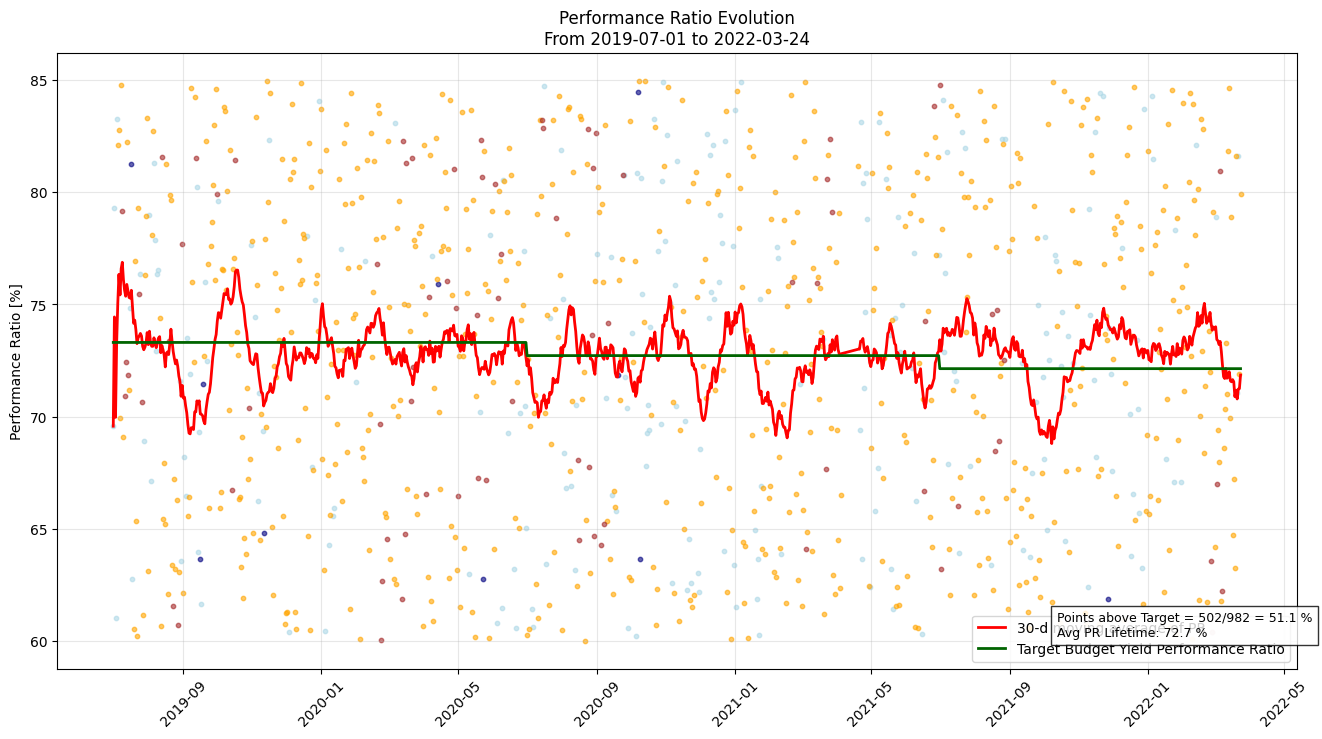

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

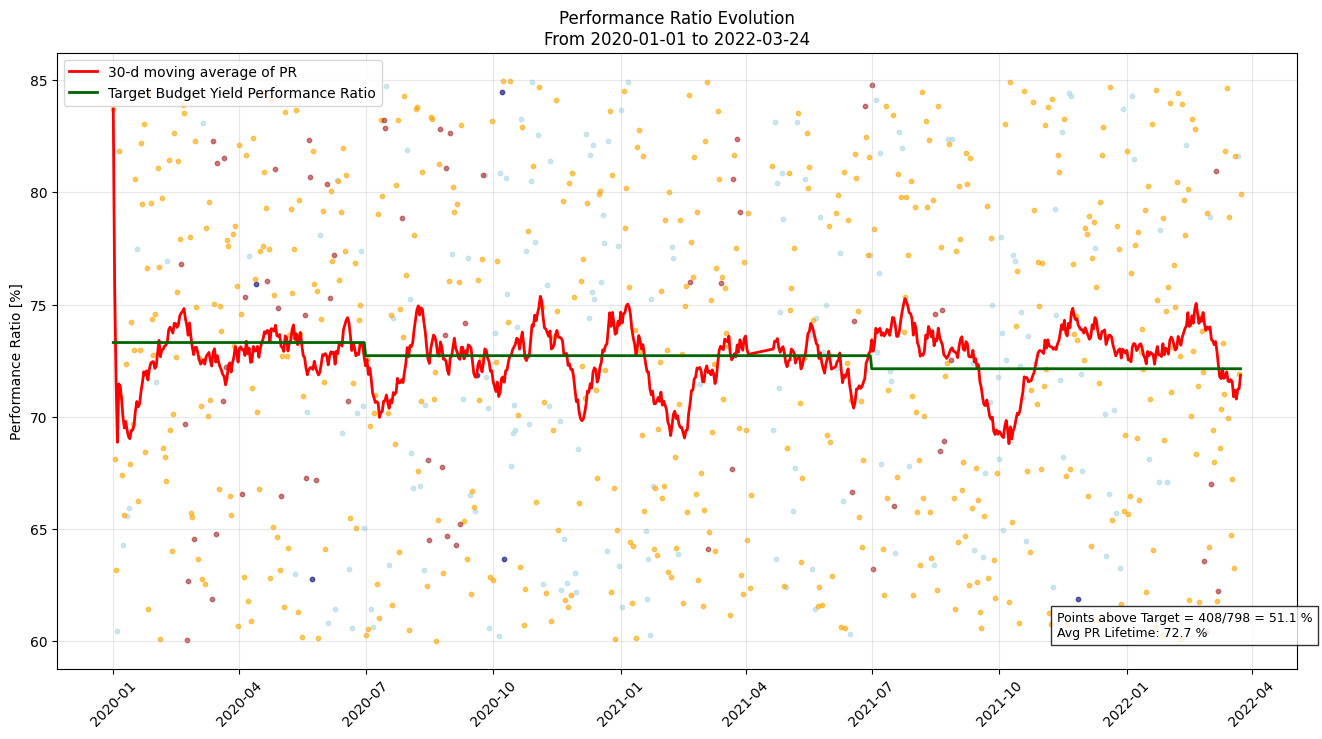

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from google.colab import files
import zipfile

zip_file_path = "/content/data.zip"
extracted_path = "/content/unzipped_data"

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_path)

BASE_PATH = os.path.join(extracted_path, 'data')
print(f"Using BASE_PATH: {BASE_PATH}")
print("Folders found:", os.listdir(BASE_PATH))

def create_collated_csv(base_path, output_file="PR_GHI_data.csv"):
    def load_param(param):
        file_list = glob.glob(os.path.join(base_path, param, "*", "*.csv"))
        file_list += glob.glob(os.path.join(base_path, param, "*.csv"))

        print(f"Found {len(file_list)} files in {param}")
        dfs = []
        for f in file_list:
            df = pd.read_csv(f)
            df.columns = ['Date', param]
            df['Date'] = pd.to_datetime(df['Date'])
            dfs.append(df)
        return pd.concat(dfs).drop_duplicates('Date').sort_values('Date')

    pr_df = load_param("PR")
    ghi_df = load_param("GHI")
    final_df = pd.merge(pr_df, ghi_df, on="Date", how="inner")
    final_df.to_csv(output_file, index=False)
    print(f"CSV Created! {len(final_df)} rows saved as {output_file}")
    return final_df

#PLOT GRAPH
def plot_performance_ratio(df, start_date=None, end_date=None, output_file="PR_GHI_data.csv"):
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

    if start_date: df = df[df['Date'] >= pd.to_datetime(start_date)]
    if end_date: df = df[df['Date'] <= pd.to_datetime(end_date)]

    if df.empty:
        print(f"No data found in the given date range: {start_date} to {end_date}.")
        return

    df['PR_30MA'] = df['PR'].rolling(window=30, min_periods=1).mean()
    df['Budget'] = df['Date'].apply(lambda d: 73.9 * ((1 - 0.008) ** (d.year - 2019 + (d.month >= 7))))

    conditions = [df['GHI'] < 2, (df['GHI'] >= 2) & (df['GHI'] < 4), (df['GHI'] >= 4) & (df['GHI'] < 6), df['GHI'] >= 6]
    choices = ['navy', 'lightblue', 'orange', 'brown']
    df['Color'] = np.select(conditions, choices, default='gray')

    plt.figure(figsize=(16, 8))
    for c in ['navy', 'lightblue', 'orange', 'brown']:
        plt.scatter(df[df['Color']==c]['Date'], df[df['Color']==c]['PR'], c=c, s=10, alpha=0.6)
    plt.plot(df['Date'], df['PR_30MA'], color='red', linewidth=2, label='30-d moving average of PR')
    plt.plot(df['Date'], df['Budget'], color='darkgreen', linewidth=2, label='Target Budget Yield Performance Ratio')

    plt.title(f"Performance Ratio Evolution\nFrom {df['Date'].min().date()} to {df['Date'].max().date()}")
    plt.ylabel("Performance Ratio [%]")
    plt.legend(); plt.grid(True, alpha=0.3); plt.xticks(rotation=45)

    points_above = (df['PR'] > df['Budget']).sum()
    stats = f"Points above Target = {points_above}/{len(df)} = {points_above/len(df)*100:.1f} %\nAvg PR Lifetime: {df['PR'].mean():.1f} %"
    plt.figtext(0.75, 0.15, stats, ha="left", fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

    filename = f"PR_Evolution_{df['Date'].min().date()}_to_{df['Date'].max().date()}.png"
    plt.savefig(filename, dpi=300)
    plt.show()

    df.to_csv(output_file, index=False)
    files.download(output_file)
    files.download(filename)

data = create_collated_csv(BASE_PATH)
plot_performance_ratio(data, output_file="PR_GHI_data.csv")

plot_performance_ratio(data, start_date="2020-01-01", end_date="2022-06-30", output_file="PR_GHI_data_2024_H1.csv")